# Configuración e importación de datos

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# 1. Cargamos el dataset procesado
df = pd.read_csv('../data/processed/df_consolidado_clean.csv')

# 2. Diccionario para renombrar las columnas a español profesional
columnas_espanol = {
    'Age': 'Edad',
    'Attrition': 'Rotacion',
    'BusinessTravel': 'Viajes_Negocio',
    'Department': 'Departamento',
    'DistanceFromHome': 'Distancia_Casa',
    'Education': 'Nivel_Educativo',
    'EducationField': 'Campo_Estudios',
    'EmployeeCount': 'Conteo_Empleados',
    'EmployeeID': 'ID_Empleado',
    'Gender': 'Genero',
    'JobLevel': 'Nivel_Puesto',
    'JobRole': 'Rol_Trabajo',
    'MaritalStatus': 'Estado_Civil',
    'MonthlyIncome': 'Ingreso_Mensual',
    'NumCompaniesWorked': 'Num_Empresas_Anteriores',
    'Over18': 'Mayor_Edad',
    'PercentSalaryHike': 'Porcentaje_Aumento_Sueldo',
    'StandardHours': 'Horas_Estandar',
    'StockOptionLevel': 'Opciones_Acciones',
    'TotalWorkingYears': 'Anos_Experiencia_Total',
    'TrainingTimesLastYear': 'Capacitaciones_Ano_Pasado',
    'YearsAtCompany': 'Anos_En_Compania',
    'YearsSinceLastPromotion': 'Anos_Desde_Ultimo_Ascenso',
    'YearsWithCurrManager': 'Anos_Con_Jefe_Actual',
    'EnvironmentSatisfaction': 'Satisfaccion_Entorno',
    'JobSatisfaction': 'Satisfaccion_Trabajo',
    'WorkLifeBalance': 'Equilibrio_Vida_Laboral',
    'JobInvolvement': 'Implicacion_Trabajo',
    'PerformanceRating': 'Evaluacion_Desempeno'
    # 'Dias_Absentismo' y 'Media_Horas_Diarias' ya están en español
}

# Aplicamos el cambio de nombre
df.rename(columns=columnas_espanol, inplace=True)

print("--- DATASET TRADUCIDO CON ÉXITO ---")
print(f"Columnas actuales: {df.shape[1]} cargadas correctamente.")

--- DATASET TRADUCIDO CON ÉXITO ---
Columnas actuales: 31 cargadas correctamente.


# Histograma de Absentismo

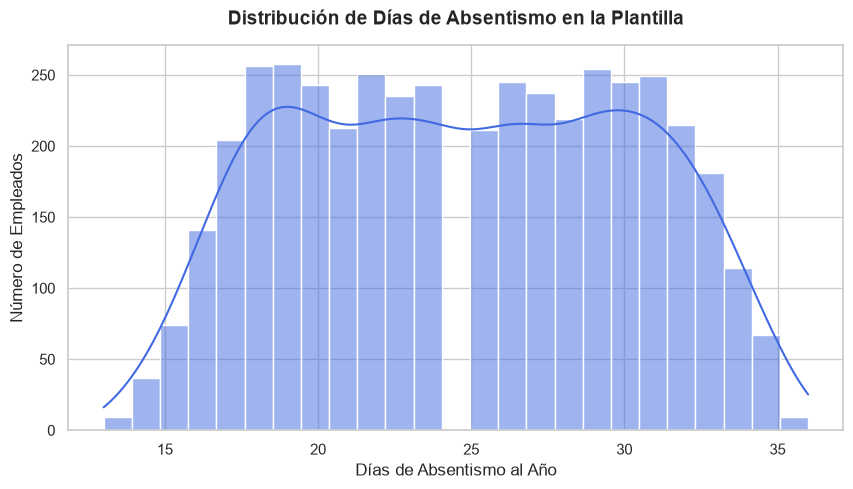

In [10]:
#Creamos un histograma para visualizar la distribución de los días de absentismo.
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Dias_Absentismo', kde=True, color='royalblue', bins=25)

# Personalizamos los títulos.
plt.title('Distribución de Días de Absentismo en la Plantilla', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Días de Absentismo al Año', fontsize=12)
plt.ylabel('Número de Empleados', fontsize=12)

#Mostramos el gráfico.
plt.show()

# Mapa de calor de correlaciones

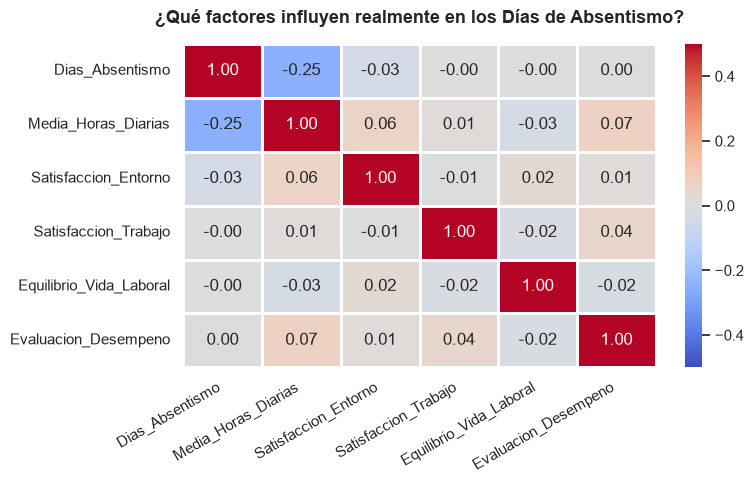

In [ ]:
# 1. Seleccionamos solo las variables clave que queremos contrastar.
variables_clave = [
    'Dias_Absentismo', 
    'Media_Horas_Diarias', 
    'Satisfaccion_Entorno', 
    'Satisfaccion_Trabajo', 
    'Equilibrio_Vida_Laboral',
    'Evaluacion_Desempeno'
]

# 2. Calculamos la correlación solo para este grupo seleccionado.
matriz_simplificada = df[variables_clave].corr()

# 3. Dibujamos un mapa de calor mucho más limpio y fácil de leer.
plt.figure(figsize=(8, 5))
sns.heatmap(
    matriz_simplificada, 
    annot=True,          # Muestra los números internos
    cmap='coolwarm',     # Rojo = Relación positiva, Azul = Relación inversa
    fmt=".2f", 
    linewidths=1, 
    vmin=-0.5, vmax=0.5  # Ajustamos el contraste para resaltar lo importante
)

plt.title('¿Qué factores influyen realmente en los Días de Absentismo?', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Relacion entre Horas Trabajadas y Absentismo.

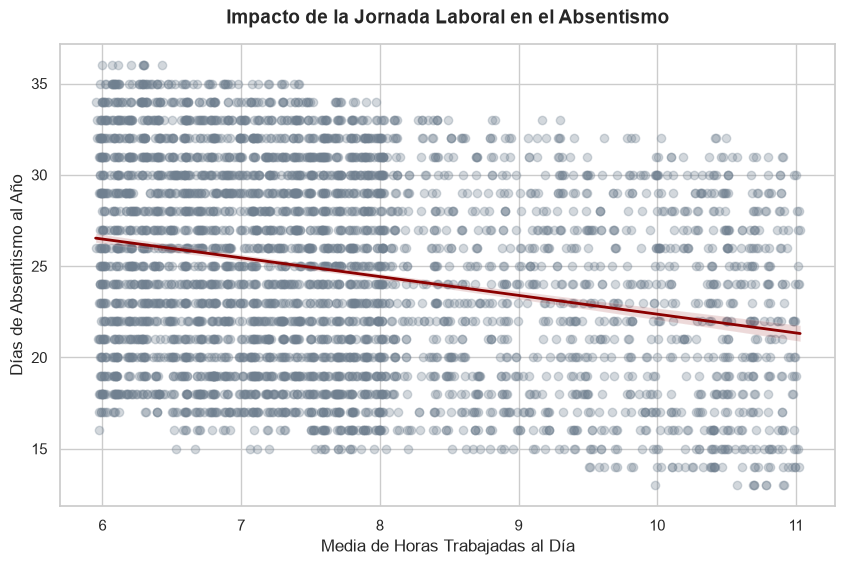

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creamos un gráfico de dispersión con línea de regresión para ver la tendencia
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df, 
    x='Media_Horas_Diarias', 
    y='Dias_Absentismo', 
    scatter_kws={'alpha':0.3, 'color': 'slategray'}, # Puntos semi-transparentes para evitar saturación
    line_kws={'color': 'darkred', 'linewidth': 2}     # Línea de tendencia roja
)

plt.title('Impacto de la Jornada Laboral en el Absentismo', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Media de Horas Trabajadas al Día', fontsize=12)
plt.ylabel('Días de Absentismo al Año', fontsize=12)

plt.show()

# Analizar Variables Categóricas 
(El impacto del Departamento o el RoI).

C:\Users\rever\AppData\Local\Temp\ipykernel_27668\473791389.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


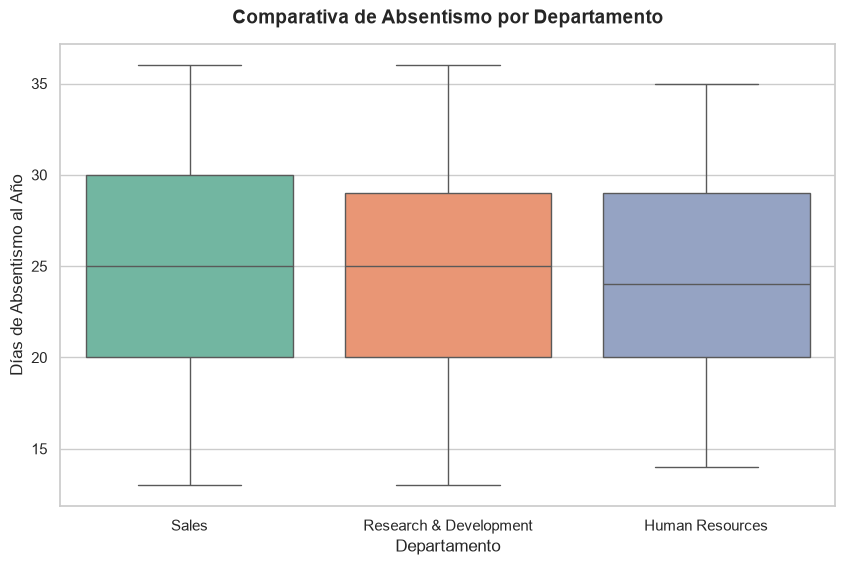

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creamos un gráfico de caja para comparar los departamentos
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df, 
    x='Departamento', 
    y='Dias_Absentismo', 
    palette='Set2' # Nos da una combinación de colores pastel muy ejecutiva
)

plt.title('Comparativa de Absentismo por Departamento', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Departamento', fontsize=12)
plt.ylabel('Días de Absentismo al Año', fontsize=12)

plt.show()

# Traducir el contenido interno y analizar el Rol de Trabajo

C:\Users\rever\AppData\Local\Temp\ipykernel_27668\1200003913.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Rol_Trabajo', y='Dias_Absentismo', palette='Set3')


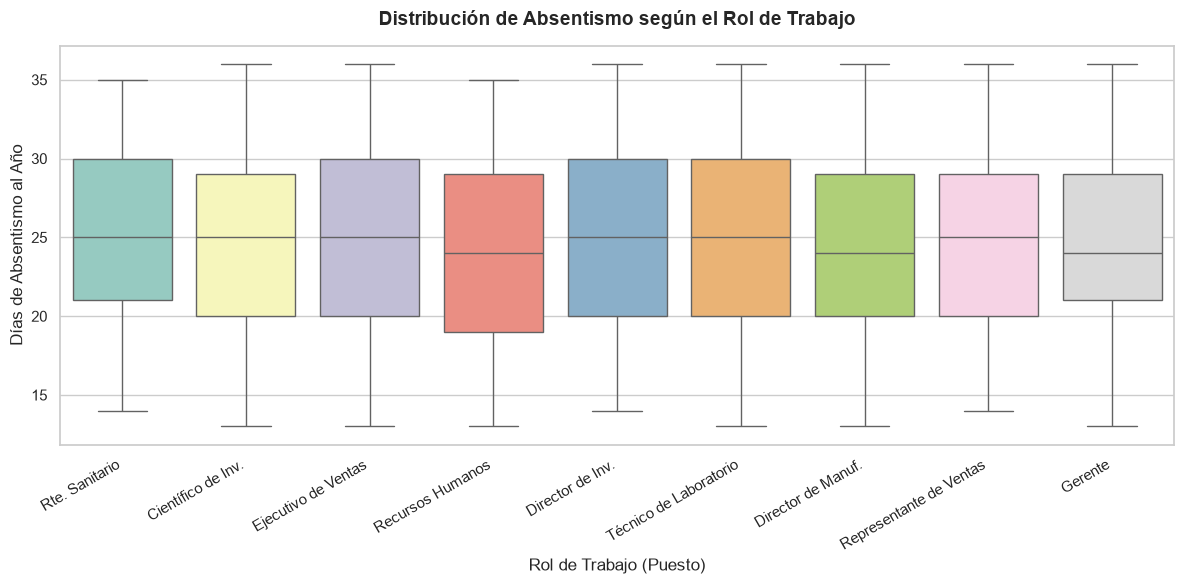

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Traducimos los textos internos de Departamento y Rol de Trabajo a español
dicc_dept = {'Sales': 'Ventas', 'Research & Development': 'I+D', 'Human Resources': 'Recursos Humanos'}

dicc_roles = {
    'Healthcare Representative': 'Rte. Sanitario', 'Research Scientist': 'Científico de Inv.',
    'Laboratory Technician': 'Técnico de Laboratorio', 'Manufacturing Director': 'Director de Manuf.',
    'Healthcare Rep': 'Rte. Sanitario', 'Sales Executive': 'Ejecutivo de Ventas',
    'Sales Representative': 'Representante de Ventas', 'Research Director': 'Director de Inv.',
    'Manager': 'Gerente', 'Human Resources': 'Recursos Humanos'
}

df['Departamento'] = df['Departamento'].map(dicc_dept).fillna(df['Departamento'])
df['Rol_Trabajo'] = df['Rol_Trabajo'].map(dicc_roles).fillna(df['Rol_Trabajo'])

# 2. Graficamos el absentismo por Rol de Trabajo para ver si ahí cambian las cosas
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Rol_Trabajo', y='Dias_Absentismo', palette='Set3')

plt.title('Distribución de Absentismo según el Rol de Trabajo', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Rol de Trabajo (Puesto)', fontsize=12)
plt.ylabel('Días de Absentismo al Año', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

plt.show()